In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение библиотеки os,
# обеспечивающей выполнение функций ОС
import os


In [2]:
# Ячейка № 2

# задание функции, возвращающей
# итерированное значение z
def Julia(c):
    def Mandelbrot(z):
        for n in range(Max_Iter):
            if abs(z) > 4:
                return n
            z = z**2 + c
        return Max_Iter

    return Mandelbrot


In [ ]:
# Ячейка № 3

# задание функции, возвращающей
# значения координат
# итерированных точек
# и их цвета
def Generate_Julia_Set(X_range, Y_range, c):
    # инициализация массива J_set
    J_set = np.zeros((len(X_range), len(Y_range)))

    for i, X in enumerate(X_range):
        for j, Y in enumerate(Y_range):
            z = complex(X, Y)
            # вызов функции Julia
            J_set[i, j] = Julia(c)(z)

    return J_set

In [ ]:
# Ячейка № 4

# задание размера
# размера изображения
# множества Жюлиа в пикселях
Rows, Cols = 800, 800

# Максимальное значение
# числа итераций, реализуемых
# для вычисления множества Жюлиа
Max_Iter = 1500

# задание координат
# графического окна
X_min = -2.0
X_max = 2.0

Y_min = -2.0
Y_max = 2.0

# создание папку 'Julia',
# используемой для сохранения
# изображений множества Жюлиа,
# если она не было создана ранее
Output_Dir = "Julia"
os.makedirs(Output_Dir, exist_ok=True)

# задание значений узлов координатных сеток
X_values = np.linspace(X_min, X_max, Cols)
Y_values = np.linspace(Y_min, Y_max, Rows)

# задание набора значений констант с
# отображения z^2 + c
c_values = [
    -0.1244 + 0.756j,
    -0.5251993 + 0.5251993j,
    -0.7 + 0.27015j,
    -0.4 + 0.6j,
    0.355 + 0.355j,
    0.0 + 0.0j,
]
# генерация изображений множеств Мандельброта
# для отображений
# и их сохранение в соответствующие файлы
for c in c_values:
    # вычисление значений
    # значений яркости изображения
    # множества Жюлиа, задаваемого
    # отображением z^2 - c[i]
    Julia_Image = Generate_Julia_Set(X_values, Y_values, c)

    # вычисление значений
    # логарифма яркости изображения
    # множества Жюлиа, задаваемого
    # отображением z^2 + c[i]
    Normed_Image = np.log(Julia_Image + 1)

    # нормировка логарифма яркости
    # пикселей изображения фрактала
    # на его максимальное значение
    Normed_Image = Normed_Image / np.max(Normed_Image)

    # визуализация изображения фрактала
    plt.imshow(Normed_Image, extent=(X_min, X_max, Y_min, Y_max), cmap="hot")
    plt.axis("off")

    # сохранение изображения
    # множества Жюлиа в
    # папке /Contens/Julia в
    # соответствующих файлах,
    # шаблон имени файла:
    # Julis_set_c_Re(c[i])_Im(c[i]).png
    plt.savefig(
        os.path.join(Output_Dir, f"Julia_set_c_{c.real:.3f}_{c.imag:.3f}.png"),
        dpi=300,
        bbox_inches="tight",
    )

    # закрытие текущего изображения
    # с целью недопущения
    # их наложений друг на друга

    plt.close()

In [5]:
# Ячейка № 5

# задание функции, возвращающей значения
# неподвижных точек отображения z^2+c
def Revers_Iteration(Z, c):
    # входные переменные:
    # Z - массив значений неподвижных точек\
    #     отображения z^2 + c
    # c - значение параметра преобразования
    N = len(Z)
    k = 0

    # инициализация массива,
    # используемого для хранения
    # значений неподвижных точек
    # соответствующем шаге
    # итерационного процесса
    z = np.zeros(2 * N) * 1j

    # реализация очередной итерации
    k = 0
    for i in range(N):
        z[k] = np.sqrt(Z[i] - c)
        z[k + 1] = -z[k]
        k = k + 2

    return z

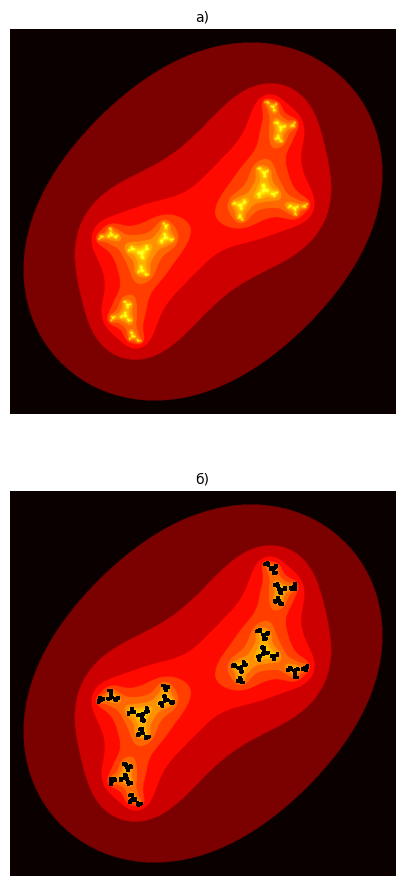

In [ ]:
# Ячейка № 6

# вычисление неподвижных точек
# отображения z^2 - 1.2j и
# их визуализация на изображении
# множества Жюлиа

# задание размера
# размера изображения
# множества Жюлиа в пикселях
Rows, Cols = 800, 800

# задание числа итераций
Level = 20

# задание значения параметра с
c = -1.2j

# определение размера
# графического окна
a = max(2, 2 * np.sqrt(np.abs(c)))

# задание координат
# графического окна
X_min = -a
X_max = a

Y_min = -a
Y_max = a


# задание значений узлов координатных сеток
X_values = np.linspace(X_min, X_max, Cols)
Y_values = np.linspace(Y_min, Y_max, Rows)

# вычисление значений
# яркости изображения
# множества Жюлиа,
# задаваемого отображением z^2 - 1.2j
Julia_Image = Generate_Julia_Set(X_values, Y_values, 1.2j)
# вычисление логарифма яркости
Normed_Image = np.log(Julia_Image + 1)

# нормировка логарифма яркости
# пикселей изображения фрактала
# на его максимальное значение
Normed_Image = Normed_Image / np.max(Normed_Image)

# вычисление первой
# отталкивающей периодической точки
w = np.sqrt(1 - 4 * c)
z1 = (1 + w) / 2
z2 = (1 - w) / 2

# удержание неподвижной
# отталкивающей точки, имеющей
# наибольшее значение модуля z
if np.abs(z1) > abs(z2):
    z = z1
else:
    z = z2

# выполнение первой итерации
w = np.sqrt(z - c)
z = np.array([w, -w])

# выполнение последующих итераций
k = 0
while k <= Level:
    k = k + 1
    z = Revers_Iteration(z, c)

# визуализация множества Жюлиа
F = plt.figure(figsize=(13, 11))
ax = F.add_subplot(2, 1, 1)
ax.imshow(Normed_Image, extent=(X_min, X_max, Y_min, Y_max), cmap="hot")
plt.axis(False)
plt.title("а)", fontsize=10)

# совместная визуализация множества Жюлиа и
# неподвижных точек отображения z^2-1.2j
ax = F.add_subplot(2, 1, 2)
ax.imshow(Normed_Image, extent=(X_min, X_max, Y_min, Y_max), cmap="hot")
plt.plot(np.imag(z), np.real(z), ".k", markersize=0.1)
plt.axis(False)
plt.title("б)", fontsize=10)

plt.show()